# NLU - Assignment 2 | Problem 1: Learning Word Embeddings from IIT Jodhpur Data
### Word2Vec: From Scratch (CBOW + Skip-gram) vs Gensim

In [2]:
# Install required libraries
!pip install gensim wordcloud matplotlib scikit-learn numpy torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.6 MB/s eta 0:00:00


In [3]:
import re
import string
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter
from wordcloud import WordCloud
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import gensim
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
print('All libraries loaded successfully.')

All libraries loaded successfully.


## TASK 1: Dataset Preparation & Preprocessing

In [4]:
CORPUS_PATH = 'raw_corpus.txt'

with open(CORPUS_PATH, 'r', encoding='utf-8', errors='ignore') as f:
    raw_text = f.read()

print(f'Raw corpus loaded. Total characters: {len(raw_text):,}')
print('First 500 chars:')
print(raw_text[:500])

Raw corpus loaded. Total characters: 251,210
First 500 chars:
ACADEMIC PROGRAMMES
Rules & Regulations
(For Students enrolled from July 2019 onwards)
​ ​
Indian Institute of Technology Jodhpur
1
1. INTRODUCTION
​ ​
Academic programmes at Indian Institute of Technology, Jodhpur are designed to develop the
highest calibre human resource capable of understanding the new patterns of knowledge
creation across disciplines obliterating traditional boundaries between science, humanities,
social sciences and engineering. IIT Jodhpur aims to produce quality professio


In [5]:
def preprocess_corpus(text):
    """
    Full preprocessing pipeline:
    1. Remove non-ASCII / non-English characters (removes Hindi/other scripts)
    2. Remove URLs, emails, and common boilerplate patterns
    3. Remove digits-only tokens and excessive punctuation
    4. Lowercase
    5. Tokenize into sentences, then words
    Returns: list of sentences, each sentence is a list of tokens
    """
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    # Remove non-ASCII characters (removes Hindi, special symbols)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    # Remove standalone numbers (page numbers, years kept if part of words)
    text = re.sub(r'\b\d+\b', ' ', text)
    # Remove excessive punctuation — keep only basic sentence punctuation
    text = re.sub(r'[^a-zA-Z\s\.\,\!\?]', ' ', text)
    # Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Lowercase the entire text
    text = text.lower()

    # Split into sentences on . ! ?
    sentences_raw = re.split(r'[.!?]', text)

    sentences = []
    for sent in sentences_raw:
        # Tokenize: split on whitespace
        tokens = sent.strip().split()
        # Filter: keep tokens that are purely alphabetic and length >= 2
        tokens = [t for t in tokens if t.isalpha() and len(t) >= 2]
        if len(tokens) >= 3:  # Discard very short/empty sentences
            sentences.append(tokens)

    return sentences

sentences = preprocess_corpus(raw_text)

# Flatten all tokens for statistics
all_tokens = [token for sent in sentences for token in sent]
vocab_counter = Counter(all_tokens)
vocab = sorted(vocab_counter.keys())

print('\n── DATASET STATISTICS ──────────────────────────────')
print(f'Total sentences (documents): {len(sentences):,}')
print(f'Total tokens:                {len(all_tokens):,}')
print(f'Vocabulary size:             {len(vocab):,}')
print(f'Top 20 words: {vocab_counter.most_common(20)}')


── DATASET STATISTICS ──────────────────────────────
Total sentences (documents): 1,945
Total tokens:                33,631
Vocabulary size:             2,678
Top 20 words: [('the', 2534), ('of', 1574), ('and', 1024), ('to', 869), ('in', 835), ('for', 690), ('be', 543), ('student', 389), ('or', 340), ('will', 321), ('by', 316), ('with', 286), ('is', 279), ('as', 277), ('course', 274), ('engineering', 251), ('students', 249), ('on', 239), ('program', 210), ('degree', 206)]


Cleaned corpus saved to cleaned_corpus.txt


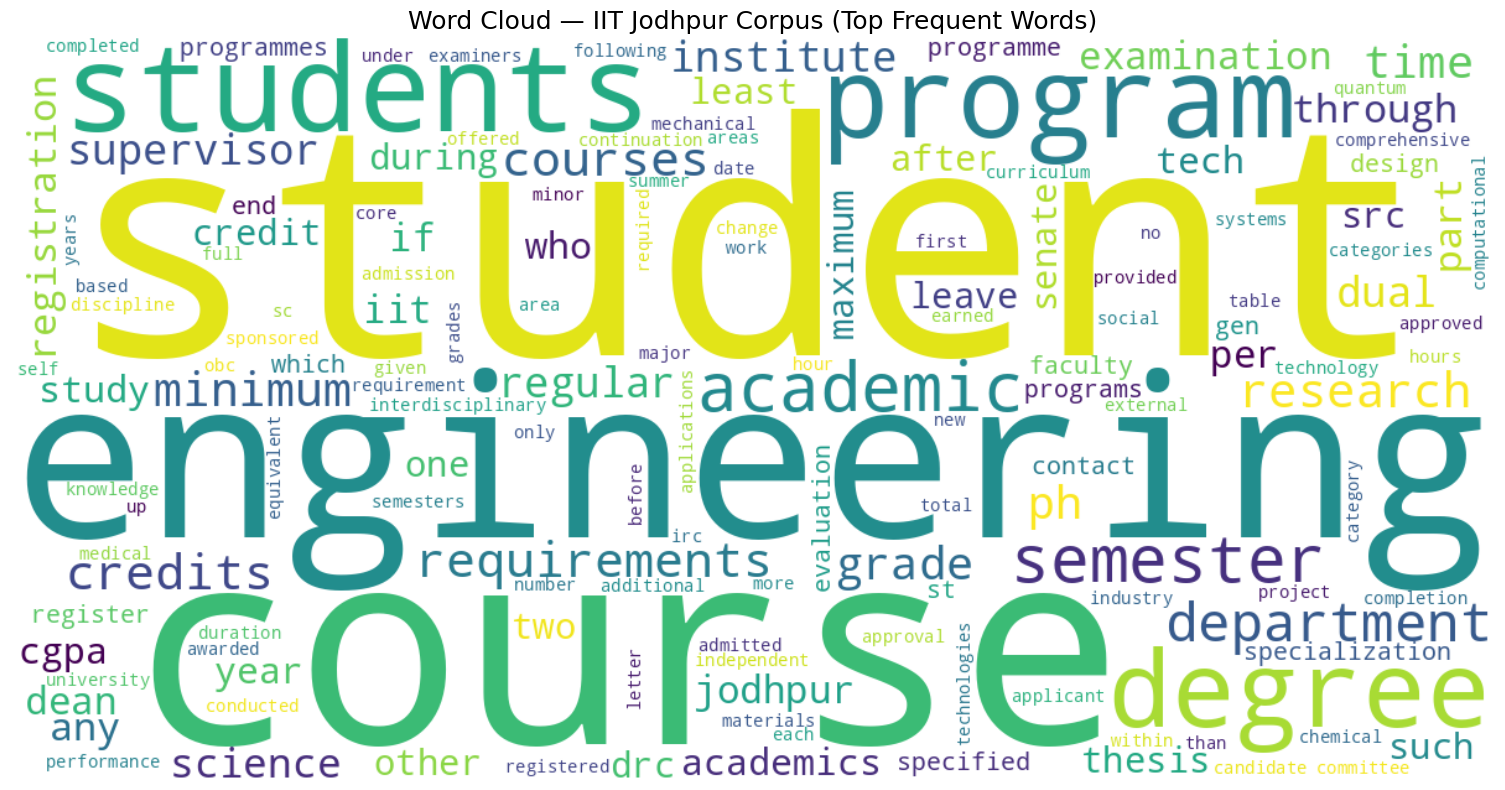

Word cloud saved.


In [6]:
# Save the cleaned corpus
with open('cleaned_corpus.txt', 'w') as f:
    for sent in sentences:
        f.write(' '.join(sent) + '\n')
print('Cleaned corpus saved to cleaned_corpus.txt')

# ── Word Cloud ───────────────────────────────────────────────────────────────
# Define stopwords to exclude very common English function words from the cloud
STOPWORDS = set(['the','a','an','is','are','was','were','be','been','being',
                 'have','has','had','do','does','did','will','would','shall',
                 'should','may','might','must','can','could','of','in','to',
                 'for','on','at','by','from','with','as','or','and','but',
                 'not','it','its','this','that','these','those','their','they',
                 'we','our','you','your','he','she','his','her','all','also'])

filtered_freq = {w: c for w, c in vocab_counter.items() if w not in STOPWORDS}

wc = WordCloud(width=1200, height=600, background_color='white',
               colormap='viridis', max_words=150).generate_from_frequencies(filtered_freq)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — IIT Jodhpur Corpus (Top Frequent Words)', fontsize=18)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150)
plt.show()
print('Word cloud saved.')

## TASK 2: Word2Vec — From Scratch (PyTorch)

In [7]:
# ── Build vocabulary with min_count filtering ────────────────────────────────
MIN_COUNT = 2  # Ignore words appearing fewer than this many times

filtered_vocab = {w for w, c in vocab_counter.items() if c >= MIN_COUNT}
# Add special unknown token
word2idx = {w: i for i, w in enumerate(sorted(filtered_vocab))}
idx2word = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(word2idx)

print(f'Filtered vocabulary size (min_count={MIN_COUNT}): {VOCAB_SIZE:,}')

# Filter sentences to only keep tokens in filtered_vocab
filtered_sentences = [[w for w in sent if w in word2idx] for sent in sentences]
filtered_sentences = [s for s in filtered_sentences if len(s) >= 3]

Filtered vocabulary size (min_count=2): 1,886


In [8]:
# ── CBOW Dataset ─────────────────────────────────────────────────────────────
# CBOW: given context words → predict center word
class CBOWDataset(Dataset):
    def __init__(self, sentences, word2idx, window_size=2):
        self.data = []  # List of (context_indices, target_index)
        for sent in sentences:
            idxs = [word2idx[w] for w in sent if w in word2idx]
            for i, target in enumerate(idxs):
                # Collect context indices within window (exclude center)
                context = [idxs[j] for j in range(max(0, i-window_size),
                                                    min(len(idxs), i+window_size+1))
                           if j != i]
                if len(context) == 0:
                    continue
                self.data.append((context, target))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        context, target = self.data[idx]
        return torch.tensor(context, dtype=torch.long), torch.tensor(target, dtype=torch.long)

def cbow_collate(batch):
    """Custom collate to handle variable-length context by mean pooling indices."""
    contexts, targets = zip(*batch)
    # Pad contexts to same length for batching; we'll average embeddings later
    max_len = max(len(c) for c in contexts)
    padded = torch.zeros(len(contexts), max_len, dtype=torch.long)
    lengths = []
    for i, c in enumerate(contexts):
        padded[i, :len(c)] = c
        lengths.append(len(c))
    return padded, torch.tensor(lengths), torch.stack(targets)

print('CBOW Dataset class defined.')

CBOW Dataset class defined.


In [9]:
# ── Skip-gram Dataset with Negative Sampling ─────────────────────────────────
class SkipGramDataset(Dataset):
    def __init__(self, sentences, word2idx, window_size=2, num_neg=5, freq_counts=None):
        self.data = []           # (center, positive_context) pairs
        self.num_neg = num_neg
        self.vocab_size = len(word2idx)

        # Build (center, context) pairs
        for sent in sentences:
            idxs = [word2idx[w] for w in sent if w in word2idx]
            for i, center in enumerate(idxs):
                for j in range(max(0, i-window_size), min(len(idxs), i+window_size+1)):
                    if j != i:
                        self.data.append((center, idxs[j]))

        # Build noise distribution for negative sampling: P(w)^(3/4)
        if freq_counts is not None:
            counts = np.array([freq_counts.get(idx2word[i], 1) for i in range(self.vocab_size)],
                              dtype=np.float32)
        else:
            counts = np.ones(self.vocab_size, dtype=np.float32)
        counts = counts ** 0.75
        self.noise_dist = counts / counts.sum()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        center, pos = self.data[idx]
        # Sample negative examples (avoid sampling center or positive)
        neg = np.random.choice(self.vocab_size, size=self.num_neg, p=self.noise_dist)
        return (torch.tensor(center, dtype=torch.long),
                torch.tensor(pos, dtype=torch.long),
                torch.tensor(neg, dtype=torch.long))

print('Skip-gram Dataset class defined.')

Skip-gram Dataset class defined.


In [10]:
# ── CBOW Model ───────────────────────────────────────────────────────────────
class CBOWModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        # Embedding matrix for input (context) words
        self.embeddings = nn.Embedding(vocab_size, embed_dim)
        # Output projection: embed_dim → vocab_size (softmax over vocabulary)
        self.out_layer = nn.Linear(embed_dim, vocab_size)
        # Initialize weights with small uniform values for stable training
        nn.init.uniform_(self.embeddings.weight, -0.1, 0.1)
        nn.init.uniform_(self.out_layer.weight, -0.1, 0.1)

    def forward(self, context_idxs, lengths):
        # context_idxs: (batch, max_context_len)
        embeds = self.embeddings(context_idxs)          # (batch, max_len, embed_dim)
        # Mean-pool context embeddings (ignore padding)
        # Mask padded positions and average over real context words
        mask = torch.zeros_like(context_idxs, dtype=torch.float)  # (batch, max_len)
        for i, l in enumerate(lengths):
            mask[i, :l] = 1.0
        mask = mask.unsqueeze(-1)                       # (batch, max_len, 1)
        mean_embed = (embeds * mask).sum(dim=1) / mask.sum(dim=1)  # (batch, embed_dim)
        logits = self.out_layer(mean_embed)             # (batch, vocab_size)
        return logits

print('CBOW Model defined.')

CBOW Model defined.


In [11]:
# ── Skip-gram Model ──────────────────────────────────────────────────────────
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        # Two separate embedding matrices as in the original Word2Vec paper:
        # in_embeddings: embeddings for center words
        # out_embeddings: embeddings for context / negative words
        self.in_embeddings = nn.Embedding(vocab_size, embed_dim)
        self.out_embeddings = nn.Embedding(vocab_size, embed_dim)
        nn.init.uniform_(self.in_embeddings.weight, -0.1, 0.1)
        nn.init.zeros_(self.out_embeddings.weight)  # init output embeds to zero

    def forward(self, center, pos_context, neg_context):
        """
        Negative Sampling objective (maximize log P(pos | center) +
        sum of log P(neg not from context | center))
        """
        # center_embed: (batch, embed_dim)
        center_embed = self.in_embeddings(center)
        # pos_embed: (batch, embed_dim)
        pos_embed = self.out_embeddings(pos_context)
        # neg_embed: (batch, num_neg, embed_dim)
        neg_embed = self.out_embeddings(neg_context)

        # Positive score: dot product of center and positive context
        pos_score = torch.sum(center_embed * pos_embed, dim=1)   # (batch,)
        pos_loss  = -torch.log(torch.sigmoid(pos_score) + 1e-10)

        # Negative score: dot product with each negative sample
        neg_score = torch.bmm(neg_embed, center_embed.unsqueeze(2)).squeeze(2)  # (batch, num_neg)
        neg_loss  = -torch.sum(torch.log(torch.sigmoid(-neg_score) + 1e-10), dim=1)

        return (pos_loss + neg_loss).mean()

    def get_embeddings(self):
        """Return the input (center-word) embeddings as numpy array."""
        return self.in_embeddings.weight.detach().cpu().numpy()

print('Skip-gram Model defined.')

Skip-gram Model defined.


In [12]:
# ── Training Function ────────────────────────────────────────────────────────
def train_model(model, dataloader, optimizer, epochs, model_name, is_skipgram=False):
    """Generic training loop. Returns list of per-epoch average losses."""
    model.train()
    loss_history = []
    for epoch in range(epochs):
        total_loss = 0.0
        n_batches = 0
        for batch in dataloader:
            optimizer.zero_grad()
            if is_skipgram:
                center, pos, neg = batch
                loss = model(center, pos, neg)
            else:
                context, lengths, target = batch
                logits = model(context, lengths)
                # Cross-entropy loss for CBOW
                loss = nn.CrossEntropyLoss()(logits, target)
            loss.backward()
            # Gradient clipping for stable training
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
        avg_loss = total_loss / n_batches
        loss_history.append(avg_loss)
        print(f'  [{model_name}] Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}')
    return loss_history

print('Training function defined.')

Training function defined.


In [13]:
# ── Hyperparameters — Experiment Grid ────────────────────────────────────────
# We train with multiple configs to compare (as required by Task 2)
CONFIGS = [
    {'embed_dim': 50,  'window': 2, 'num_neg': 5,  'label': 'dim=50, win=2, neg=5'},
    {'embed_dim': 100, 'window': 2, 'num_neg': 5,  'label': 'dim=100, win=2, neg=5'},
    {'embed_dim': 100, 'window': 4, 'num_neg': 5,  'label': 'dim=100, win=4, neg=5'},
    {'embed_dim': 100, 'window': 2, 'num_neg': 10, 'label': 'dim=100, win=2, neg=10'},
]

EPOCHS     = 10
BATCH_SIZE = 256
LR         = 0.001

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Store trained models for later analysis
scratch_models = {}   # key: (model_type, config_label)
scratch_losses = {}

for cfg in CONFIGS:
    print(f'\n=== Config: {cfg["label"]} ===')
    embed_dim  = cfg['embed_dim']
    window     = cfg['window']
    num_neg    = cfg['num_neg']

    # ---- CBOW ----
    cbow_ds     = CBOWDataset(filtered_sentences, word2idx, window_size=window)
    cbow_loader = DataLoader(cbow_ds, batch_size=BATCH_SIZE, shuffle=True,
                             collate_fn=cbow_collate, num_workers=0)
    cbow_model  = CBOWModel(VOCAB_SIZE, embed_dim).to(device)
    cbow_opt    = optim.Adam(cbow_model.parameters(), lr=LR)
    print(f'  CBOW trainable params: {sum(p.numel() for p in cbow_model.parameters()):,}')
    losses_cbow = train_model(cbow_model, cbow_loader, cbow_opt, EPOCHS,
                              f'CBOW|{cfg["label"]}', is_skipgram=False)
    scratch_models[('cbow', cfg['label'])] = cbow_model
    scratch_losses[('cbow', cfg['label'])] = losses_cbow

    # ---- Skip-gram ----
    sg_ds     = SkipGramDataset(filtered_sentences, word2idx, window_size=window,
                                num_neg=num_neg, freq_counts=vocab_counter)
    sg_loader = DataLoader(sg_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    sg_model  = SkipGramModel(VOCAB_SIZE, embed_dim).to(device)
    sg_opt    = optim.Adam(sg_model.parameters(), lr=LR)
    print(f'  Skip-gram trainable params: {sum(p.numel() for p in sg_model.parameters()):,}')
    losses_sg = train_model(sg_model, sg_loader, sg_opt, EPOCHS,
                            f'SG|{cfg["label"]}', is_skipgram=True)
    scratch_models[('skipgram', cfg['label'])] = sg_model
    scratch_losses[('skipgram', cfg['label'])] = losses_sg

print('\nAll scratch models trained!')

Using device: cpu

=== Config: dim=50, win=2, neg=5 ===
  CBOW trainable params: 190,486
  [CBOW|dim=50, win=2, neg=5] Epoch 1/10 — Loss: 7.3942
  [CBOW|dim=50, win=2, neg=5] Epoch 2/10 — Loss: 6.4684
  [CBOW|dim=50, win=2, neg=5] Epoch 3/10 — Loss: 5.9894
  [CBOW|dim=50, win=2, neg=5] Epoch 4/10 — Loss: 5.8652
  [CBOW|dim=50, win=2, neg=5] Epoch 5/10 — Loss: 5.7482
  [CBOW|dim=50, win=2, neg=5] Epoch 6/10 — Loss: 5.6215
  [CBOW|dim=50, win=2, neg=5] Epoch 7/10 — Loss: 5.4804
  [CBOW|dim=50, win=2, neg=5] Epoch 8/10 — Loss: 5.3403
  [CBOW|dim=50, win=2, neg=5] Epoch 9/10 — Loss: 5.1925
  [CBOW|dim=50, win=2, neg=5] Epoch 10/10 — Loss: 5.0516
  Skip-gram trainable params: 188,600
  [SG|dim=50, win=2, neg=5] Epoch 1/10 — Loss: 3.3279
  [SG|dim=50, win=2, neg=5] Epoch 2/10 — Loss: 2.6409
  [SG|dim=50, win=2, neg=5] Epoch 3/10 — Loss: 2.5072
  [SG|dim=50, win=2, neg=5] Epoch 4/10 — Loss: 2.3857
  [SG|dim=50, win=2, neg=5] Epoch 5/10 — Loss: 2.2801
  [SG|dim=50, win=2, neg=5] Epoch 6/10 — L

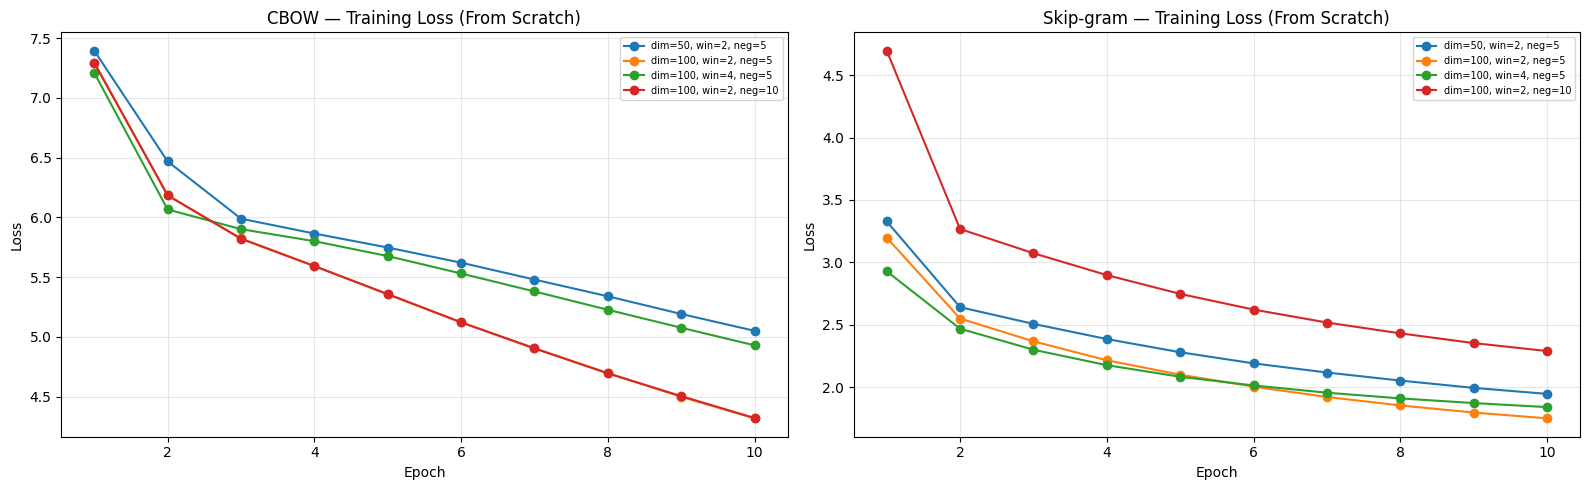

Loss curves saved.


In [14]:
# ── Plot Training Loss Curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for (mtype, label), losses in scratch_losses.items():
    ax = axes[0] if mtype == 'cbow' else axes[1]
    ax.plot(range(1, len(losses)+1), losses, marker='o', label=label)

axes[0].set_title('CBOW — Training Loss (From Scratch)')
axes[1].set_title('Skip-gram — Training Loss (From Scratch)')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves_scratch.png', dpi=150)
plt.show()
print('Loss curves saved.')

In [15]:
# ── Gensim Word2Vec (for comparison) ─────────────────────────────────────────
print('Training Gensim Word2Vec models for comparison...')

gensim_models = {}
gensim_configs = [
    {'sg': 0, 'vector_size': 100, 'window': 2, 'negative': 5,  'label': 'CBOW dim=100 win=2'},
    {'sg': 1, 'vector_size': 100, 'window': 2, 'negative': 5,  'label': 'SG   dim=100 win=2'},
    {'sg': 1, 'vector_size': 100, 'window': 4, 'negative': 5,  'label': 'SG   dim=100 win=4'},
    {'sg': 1, 'vector_size': 100, 'window': 2, 'negative': 10, 'label': 'SG   dim=100 neg=10'},
]

for cfg in gensim_configs:
    model = Word2Vec(
        sentences=filtered_sentences,
        vector_size=cfg['vector_size'],
        window=cfg['window'],
        min_count=MIN_COUNT,
        sg=cfg['sg'],           # 0 = CBOW, 1 = Skip-gram
        negative=cfg['negative'],
        epochs=EPOCHS,
        workers=4,
        seed=42
    )
    gensim_models[cfg['label']] = model
    print(f'  Trained: {cfg["label"]} | vocab size: {len(model.wv):,}')

print('\nAll Gensim models trained!')

Training Gensim Word2Vec models for comparison...
  Trained: CBOW dim=100 win=2 | vocab size: 1,886
  Trained: SG   dim=100 win=2 | vocab size: 1,886
  Trained: SG   dim=100 win=4 | vocab size: 1,886
  Trained: SG   dim=100 neg=10 | vocab size: 1,886

All Gensim models trained!


## TASK 3: Semantic Analysis

In [16]:
# ── Cosine Similarity Utility ────────────────────────────────────────────────
def cosine_similarity(v1, v2):
    """Compute cosine similarity between two 1D numpy vectors."""
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return np.dot(v1, v2) / (norm1 * norm2)

def get_embedding_scratch(model, word, word2idx, model_type='skipgram'):
    """Extract embedding vector for a word from a scratch-trained model."""
    if word not in word2idx:
        return None
    idx = torch.tensor([word2idx[word]], dtype=torch.long)
    if model_type == 'skipgram':
        return model.in_embeddings(idx).detach().cpu().numpy()[0]
    else:  # CBOW
        return model.embeddings(idx).detach().cpu().numpy()[0]

def get_all_embeddings_scratch(model, word2idx, model_type='skipgram'):
    """Return full embedding matrix from scratch model as numpy (vocab_size, dim)."""
    if model_type == 'skipgram':
        return model.in_embeddings.weight.detach().cpu().numpy()
    else:
        return model.embeddings.weight.detach().cpu().numpy()

def nearest_neighbors_scratch(word, model, word2idx, idx2word, model_type, top_k=5):
    """
    Find top_k nearest neighbors of 'word' by cosine similarity
    using scratch-trained embeddings.
    """
    query_vec = get_embedding_scratch(model, word, word2idx, model_type)
    if query_vec is None:
        return [f'Word "{word}" not in vocabulary']
    all_embeds = get_all_embeddings_scratch(model, word2idx, model_type)  # (V, D)
    # Compute cosine similarity of query with all words
    norms = np.linalg.norm(all_embeds, axis=1, keepdims=True) + 1e-10
    normed = all_embeds / norms
    query_normed = query_vec / (np.linalg.norm(query_vec) + 1e-10)
    sims = normed @ query_normed  # (V,)
    # Get top_k+1 and exclude the query word itself
    top_idxs = np.argsort(-sims)[:top_k + 10]
    results = []
    for idx in top_idxs:
        w = idx2word[idx]
        if w != word:
            results.append((w, sims[idx]))
        if len(results) == top_k:
            break
    return results

print('Similarity utilities defined.')

Similarity utilities defined.


In [17]:
# ── Top-5 Nearest Neighbors ───────────────────────────────────────────────────
# Use the best scratch config (dim=100, win=2, neg=5) and Gensim for comparison

QUERY_WORDS = ['research', 'student', 'phd', 'exam']
BEST_LABEL  = 'dim=100, win=2, neg=5'

best_cbow_scratch = scratch_models[('cbow', BEST_LABEL)]
best_sg_scratch   = scratch_models[('skipgram', BEST_LABEL)]
best_gensim_cbow  = gensim_models['CBOW dim=100 win=2']
best_gensim_sg    = gensim_models['SG   dim=100 win=2']

print('=' * 70)
print('TOP-5 NEAREST NEIGHBORS')
print('=' * 70)

for word in QUERY_WORDS:
    print(f'\n── Word: "{word}" ──')

    # Scratch CBOW
    nn_cbow = nearest_neighbors_scratch(word, best_cbow_scratch, word2idx, idx2word, 'cbow')
    print(f'  [Scratch CBOW]:    {nn_cbow}')

    # Scratch Skip-gram
    nn_sg = nearest_neighbors_scratch(word, best_sg_scratch, word2idx, idx2word, 'skipgram')
    print(f'  [Scratch SG]:      {nn_sg}')

    # Gensim CBOW
    try:
        gnn_cbow = best_gensim_cbow.wv.most_similar(word, topn=5)
        print(f'  [Gensim CBOW]:     {gnn_cbow}')
    except KeyError:
        print(f'  [Gensim CBOW]:     Word "{word}" not in vocabulary')

    # Gensim Skip-gram
    try:
        gnn_sg = best_gensim_sg.wv.most_similar(word, topn=5)
        print(f'  [Gensim SG]:       {gnn_sg}')
    except KeyError:
        print(f'  [Gensim SG]:       Word "{word}" not in vocabulary')

TOP-5 NEAREST NEIGHBORS

── Word: "research" ──
  [Scratch CBOW]:    [('diverse', np.float32(0.5709189)), ('september', np.float32(0.545788)), ('teaching', np.float32(0.5448509)), ('experimental', np.float32(0.5369146)), ('composition', np.float32(0.5360363))]
  [Scratch SG]:      [('proposal', np.float32(0.67269444)), ('library', np.float32(0.62504935)), ('collaborative', np.float32(0.6184314)), ('composition', np.float32(0.6134719)), ('representative', np.float32(0.61159116))]
  [Gensim CBOW]:     [('knowledge', 0.9981369376182556), ('understanding', 0.998075008392334), ('world', 0.9980252981185913), ('energy', 0.9978567957878113), ('new', 0.9978328943252563)]
  [Gensim SG]:       [('understanding', 0.92320317029953), ('problems', 0.9179069995880127), ('knowledge', 0.9166319966316223), ('teaching', 0.9129518270492554), ('energy', 0.9037460684776306)]

── Word: "student" ──
  [Scratch CBOW]:    [('awaiting', np.float32(0.66173536)), ('cancelled', np.float32(0.6338376)), ('there', np.f

In [18]:
# ── Analogy Experiments ───────────────────────────────────────────────────────
# Analogy: A is to B as C is to ? → find word closest to (B - A + C)

def analogy_scratch(a, b, c, model, word2idx, idx2word, model_type, top_k=5):
    """
    Solve analogy: a : b :: c : ?
    Answer = argmax cosine_similarity(embed(b) - embed(a) + embed(c), embed(w))
    Excludes a, b, c from the results.
    """
    va = get_embedding_scratch(model, a, word2idx, model_type)
    vb = get_embedding_scratch(model, b, word2idx, model_type)
    vc = get_embedding_scratch(model, c, word2idx, model_type)
    if any(v is None for v in [va, vb, vc]):
        missing = [w for w, v in zip([a,b,c],[va,vb,vc]) if v is None]
        return [f'Words not in vocab: {missing}']
    query = vb - va + vc  # Analogy vector
    all_embeds = get_all_embeddings_scratch(model, word2idx, model_type)
    norms = np.linalg.norm(all_embeds, axis=1, keepdims=True) + 1e-10
    normed = all_embeds / norms
    q_normed = query / (np.linalg.norm(query) + 1e-10)
    sims = normed @ q_normed
    top_idxs = np.argsort(-sims)
    exclude = {a, b, c}
    results = []
    for idx in top_idxs:
        w = idx2word[idx]
        if w not in exclude:
            results.append((w, sims[idx]))
        if len(results) == top_k:
            break
    return results

def analogy_gensim(a, b, c, gensim_model, top_k=5):
    """Gensim analogy: a:b :: c:?"""
    try:
        # positive=[b, c], negative=[a] computes b - a + c
        result = gensim_model.wv.most_similar(positive=[b, c], negative=[a], topn=top_k)
        return result
    except KeyError as e:
        return [f'KeyError: {e}']

# Define at least 3 analogies as required
ANALOGIES = [
    ('ug', 'btech', 'pg'),         # UG:BTech :: PG:?
    ('professor', 'research', 'student'),  # professor:research :: student:?
    ('semester', 'exam', 'course'),        # semester:exam :: course:?
]

print('=' * 70)
print('ANALOGY EXPERIMENTS')
print('=' * 70)

for a, b, c in ANALOGIES:
    print(f'\nAnalogy: "{a}" : "{b}" :: "{c}" : ?')

    res_cbow = analogy_scratch(a, b, c, best_cbow_scratch, word2idx, idx2word, 'cbow')
    print(f'  [Scratch CBOW]:  {res_cbow}')

    res_sg = analogy_scratch(a, b, c, best_sg_scratch, word2idx, idx2word, 'skipgram')
    print(f'  [Scratch SG]:    {res_sg}')

    res_gcbow = analogy_gensim(a, b, c, best_gensim_cbow)
    print(f'  [Gensim CBOW]:   {res_gcbow}')

    res_gsg = analogy_gensim(a, b, c, best_gensim_sg)
    print(f'  [Gensim SG]:     {res_gsg}')

ANALOGY EXPERIMENTS

Analogy: "ug" : "btech" :: "pg" : ?
  [Scratch CBOW]:  [('mba', np.float32(0.51587915)), ('mtech', np.float32(0.48477823)), ('degree', np.float32(0.47126696)), ('thermofluids', np.float32(0.4673225)), ('sensors', np.float32(0.45552382))]
  [Scratch SG]:    [('thermofluids', np.float32(0.7216871)), ('mba', np.float32(0.6822317)), ('mtech', np.float32(0.6685058)), ('phd', np.float32(0.66606826)), ('double', np.float32(0.65932703))]
  [Gensim CBOW]:   [('physics', 0.9956831932067871), ('advanced', 0.9953677654266357), ('industry', 0.9952609539031982), ('smart', 0.995242178440094), ('mathematics', 0.9951987862586975)]
  [Gensim SG]:     [('cps', 0.9878522157669067), ('vlsi', 0.9874966144561768), ('double', 0.9872111082077026), ('mba', 0.9871993660926819), ('entrepreneurial', 0.9866228699684143)]

Analogy: "professor" : "research" :: "student" : ?
  [Scratch CBOW]:  [('enables', np.float32(0.52043164)), ('enhance', np.float32(0.51217306)), ('campus', np.float32(0.497897

## TASK 4: Visualization — PCA and t-SNE

In [19]:
# ── Select word groups for visualization ─────────────────────────────────────
# Visualize semantically coherent clusters
WORD_GROUPS = {
    'Academic Programs': ['btech', 'mtech', 'phd', 'msc', 'pg', 'ug', 'degree', 'program'],
    'Research':          ['research', 'publication', 'paper', 'project', 'lab', 'thesis', 'faculty'],
    'Administration':    ['department', 'institute', 'committee', 'dean', 'office', 'academic'],
    'Student Life':      ['student', 'exam', 'course', 'semester', 'class', 'hostel', 'campus'],
    'Technology':        ['computer', 'engineering', 'science', 'software', 'system', 'data'],
}

# Flatten and filter to words actually in vocabulary
def filter_words_in_vocab(groups, vocab_set):
    filtered = {}
    for group, words in groups.items():
        present = [w for w in words if w in vocab_set]
        if len(present) >= 2:
            filtered[group] = present
    return filtered

scratch_vocab_set = set(word2idx.keys())
gensim_vocab_set  = set(best_gensim_sg.wv.key_to_index.keys())

scratch_groups = filter_words_in_vocab(WORD_GROUPS, scratch_vocab_set)
gensim_groups  = filter_words_in_vocab(WORD_GROUPS, gensim_vocab_set)

print('Words available for scratch visualization:')
for g, ws in scratch_groups.items():
    print(f'  {g}: {ws}')

print('\nWords available for Gensim visualization:')
for g, ws in gensim_groups.items():
    print(f'  {g}: {ws}')

Words available for scratch visualization:
  Academic Programs: ['btech', 'mtech', 'phd', 'msc', 'pg', 'ug', 'degree', 'program']
  Research: ['research', 'paper', 'project', 'lab', 'thesis', 'faculty']
  Administration: ['department', 'institute', 'committee', 'dean', 'office', 'academic']
  Student Life: ['student', 'exam', 'course', 'semester', 'class', 'campus']
  Technology: ['computer', 'engineering', 'science', 'software', 'system', 'data']

Words available for Gensim visualization:
  Academic Programs: ['btech', 'mtech', 'phd', 'msc', 'pg', 'ug', 'degree', 'program']
  Research: ['research', 'paper', 'project', 'lab', 'thesis', 'faculty']
  Administration: ['department', 'institute', 'committee', 'dean', 'office', 'academic']
  Student Life: ['student', 'exam', 'course', 'semester', 'class', 'campus']
  Technology: ['computer', 'engineering', 'science', 'software', 'system', 'data']


In [20]:
# ── Visualization Helper ──────────────────────────────────────────────────────
def get_word_vectors_scratch(groups, model, word2idx, model_type):
    """Collect embedding vectors and labels for selected word groups."""
    vectors, labels, colors_list, group_labels = [], [], [], []
    palette = plt.cm.tab10.colors
    for i, (group, words) in enumerate(groups.items()):
        for word in words:
            v = get_embedding_scratch(model, word, word2idx, model_type)
            if v is not None:
                vectors.append(v)
                labels.append(word)
                colors_list.append(palette[i % len(palette)])
                group_labels.append(group)
    return np.array(vectors), labels, colors_list, group_labels

def get_word_vectors_gensim(groups, gensim_model):
    vectors, labels, colors_list, group_labels = [], [], [], []
    palette = plt.cm.tab10.colors
    for i, (group, words) in enumerate(groups.items()):
        for word in words:
            if word in gensim_model.wv:
                vectors.append(gensim_model.wv[word])
                labels.append(word)
                colors_list.append(palette[i % len(palette)])
                group_labels.append(group)
    return np.array(vectors), labels, colors_list, group_labels

def plot_2d(vecs_2d, labels, colors_list, group_labels, groups, title, ax):
    """Plot 2D projected embeddings with word labels and group-colored points."""
    palette = plt.cm.tab10.colors
    seen_groups = set()
    for i, (x, y) in enumerate(vecs_2d):
        g = group_labels[i]
        gi = list(groups.keys()).index(g)
        label_kwarg = g if g not in seen_groups else None
        seen_groups.add(g)
        ax.scatter(x, y, color=palette[gi % len(palette)], s=80,
                   label=label_kwarg, zorder=3)
        ax.annotate(labels[i], (x, y), fontsize=8, textcoords='offset points',
                    xytext=(4, 4), alpha=0.85)
    ax.legend(fontsize=7, loc='best')
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')

print('Visualization helpers defined.')

Visualization helpers defined.


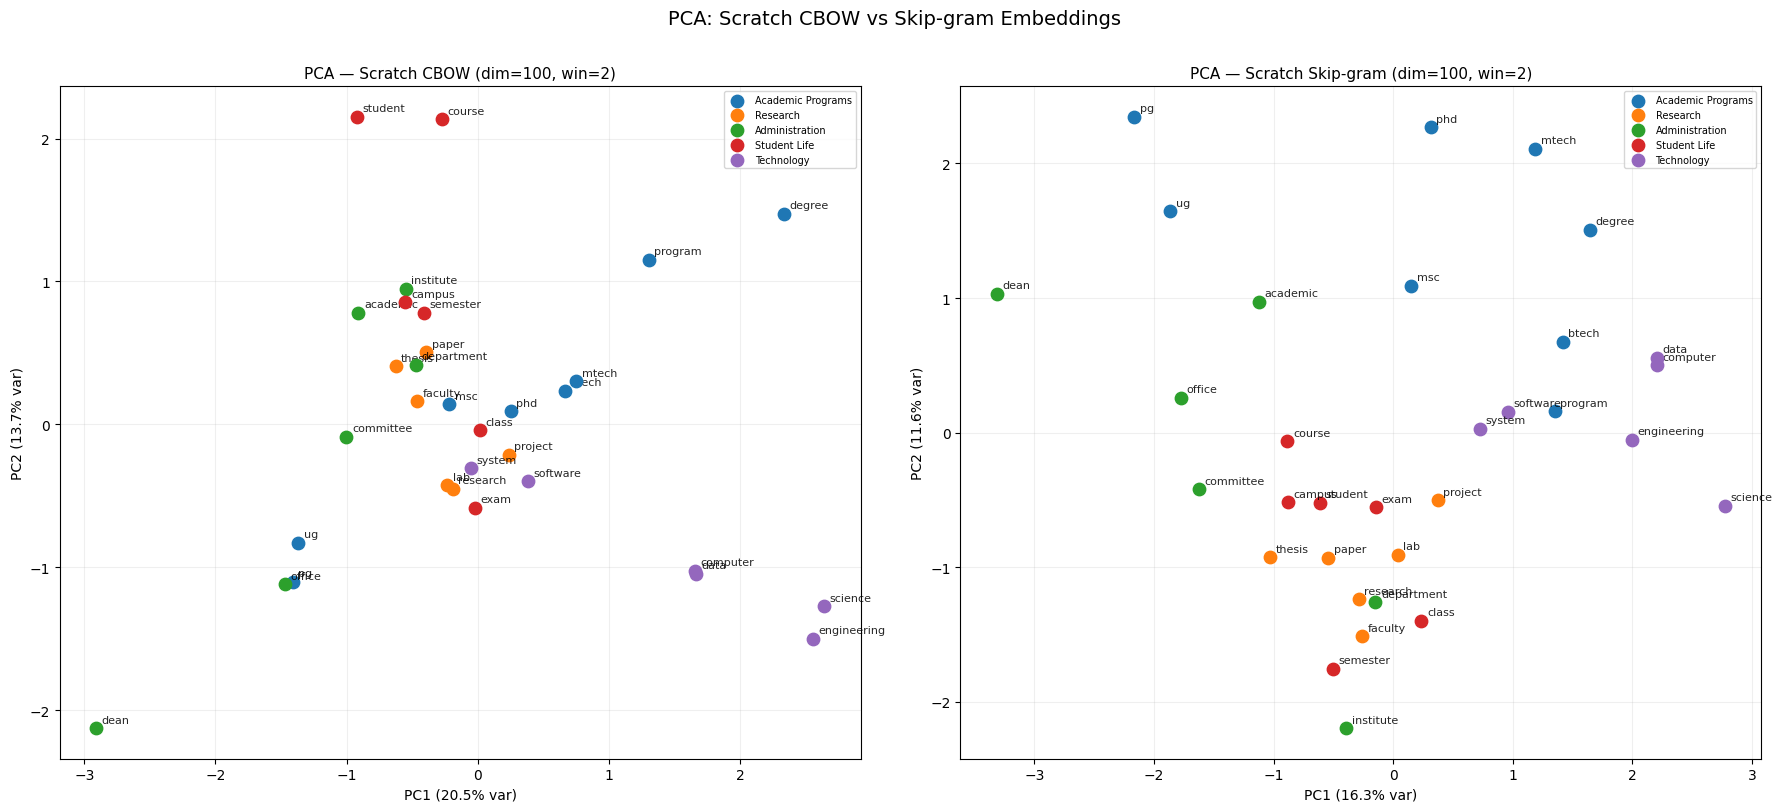

PCA scratch plot saved.


In [21]:
# ── PCA Visualization: Scratch CBOW vs Scratch Skip-gram ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, model, mtype, title in [
    (axes[0], best_cbow_scratch, 'cbow',     'PCA — Scratch CBOW (dim=100, win=2)'),
    (axes[1], best_sg_scratch,   'skipgram', 'PCA — Scratch Skip-gram (dim=100, win=2)'),
]:
    vecs, labs, cols, glabs = get_word_vectors_scratch(scratch_groups, model, word2idx, mtype)
    if len(vecs) < 2:
        ax.set_title(f'{title}\n(not enough words in vocab)')
        continue
    # PCA to 2D
    pca = PCA(n_components=2, random_state=42)
    vecs_2d = pca.fit_transform(vecs)
    plot_2d(vecs_2d, labs, cols, glabs, scratch_groups, title, ax)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')

plt.suptitle('PCA: Scratch CBOW vs Skip-gram Embeddings', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('pca_scratch.png', dpi=150, bbox_inches='tight')
plt.show()
print('PCA scratch plot saved.')

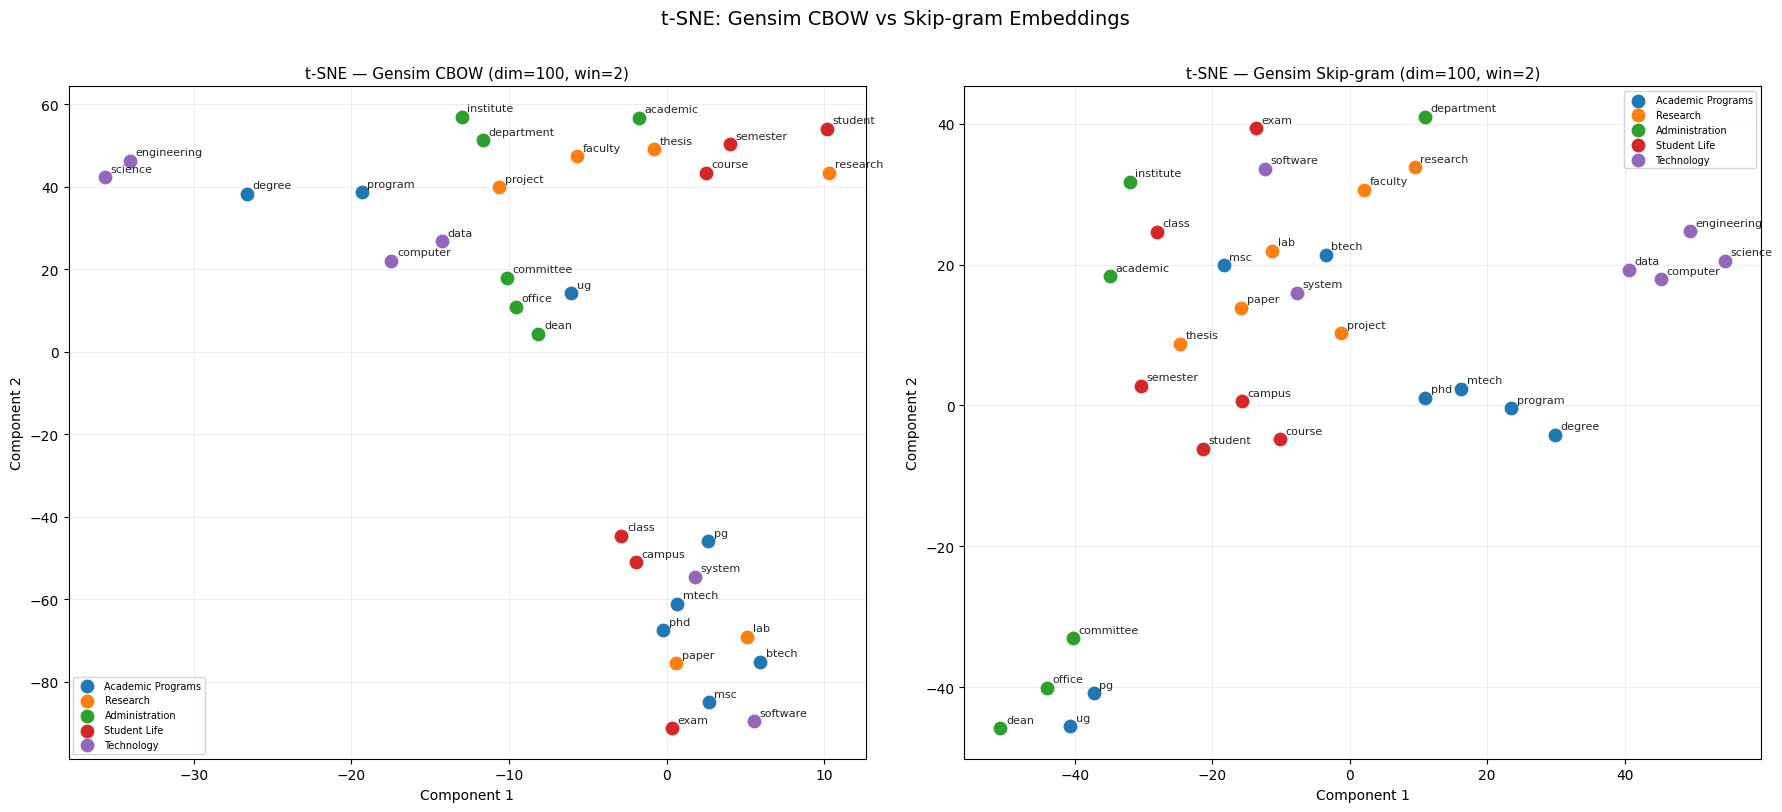

t-SNE Gensim plot saved.


In [22]:
# ── t-SNE Visualization: Gensim CBOW vs Skip-gram ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, gmodel, title in [
    (axes[0], best_gensim_cbow, 't-SNE — Gensim CBOW (dim=100, win=2)'),
    (axes[1], best_gensim_sg,   't-SNE — Gensim Skip-gram (dim=100, win=2)'),
]:
    vecs, labs, cols, glabs = get_word_vectors_gensim(gensim_groups, gmodel)
    if len(vecs) < 5:
        ax.set_title(f'{title}\n(not enough words in vocab)')
        continue
    # t-SNE to 2D (perplexity must be < n_samples)
    perp = min(5, len(vecs) - 1)
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42,
                learning_rate='auto', init='pca', n_iter=1000)
    vecs_2d = tsne.fit_transform(vecs)
    plot_2d(vecs_2d, labs, cols, glabs, gensim_groups, title, ax)

plt.suptitle('t-SNE: Gensim CBOW vs Skip-gram Embeddings', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('tsne_gensim.png', dpi=150, bbox_inches='tight')
plt.show()
print('t-SNE Gensim plot saved.')

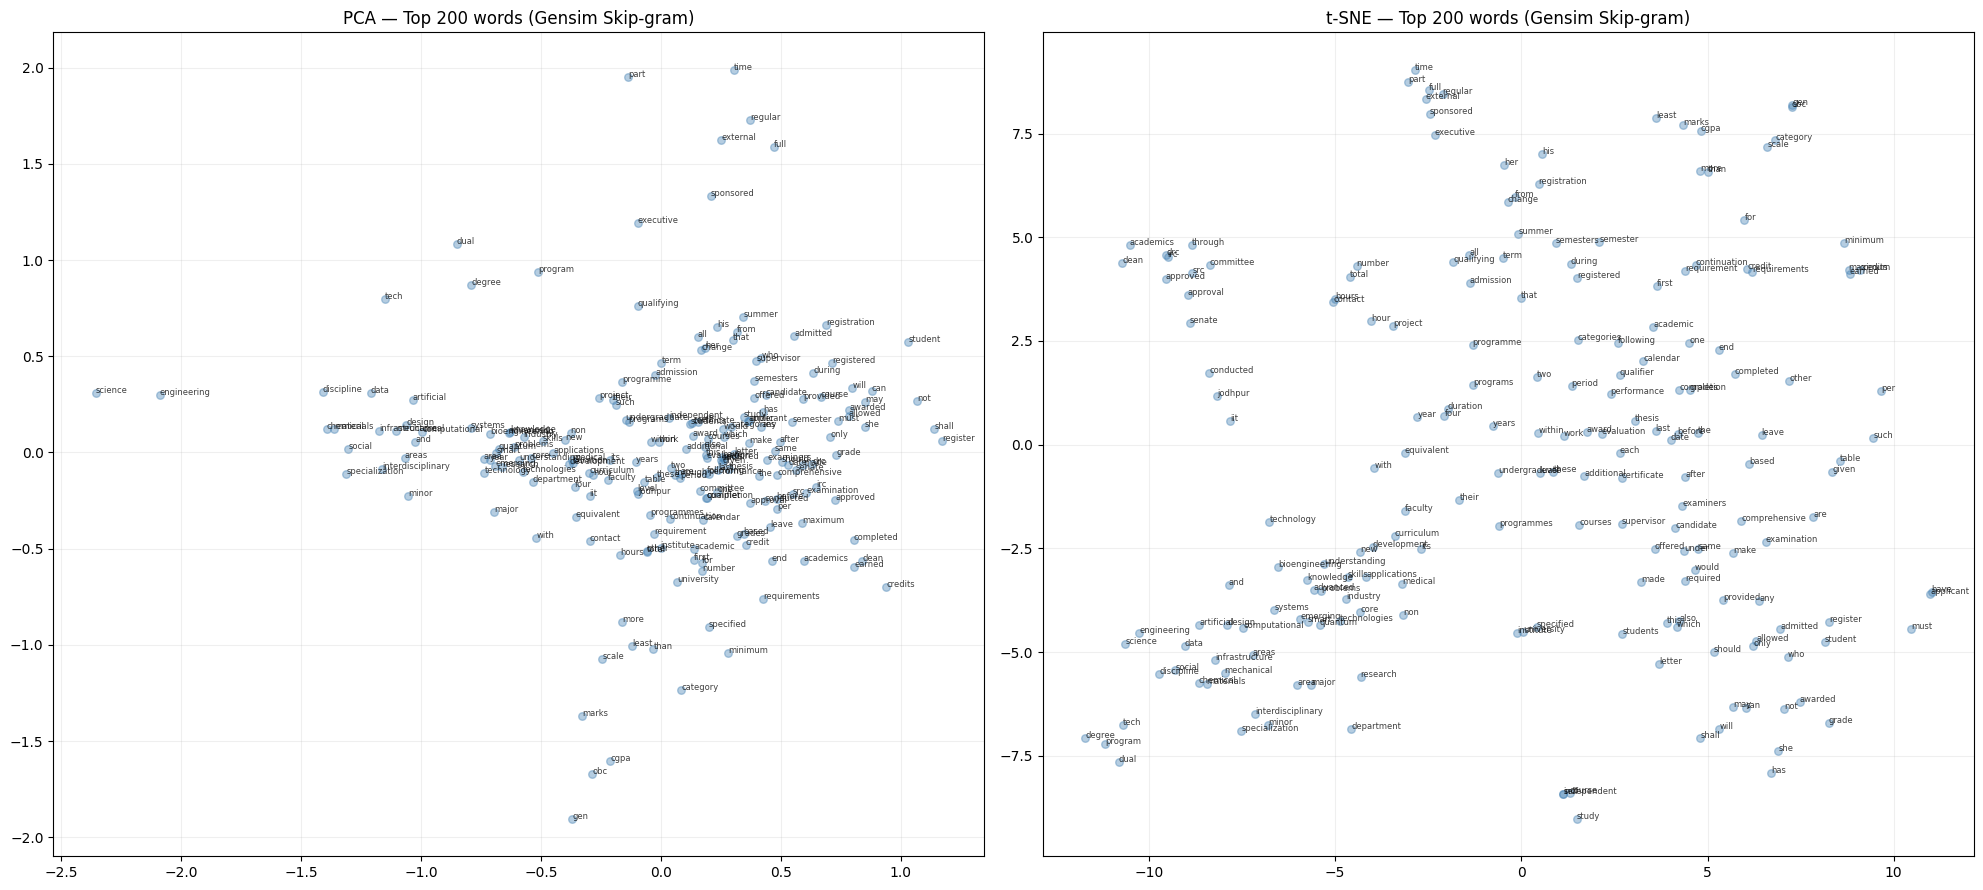

Top-200 words PCA/t-SNE saved.


In [23]:
# ── PCA + t-SNE on a larger set of words (Gensim SG) for richer visualization ─
# Grab top-200 most frequent words for a broader picture

TOP_N = 200
top_words = [w for w, _ in vocab_counter.most_common(TOP_N + 50)
             if w in best_gensim_sg.wv and len(w) > 2]
top_words = top_words[:TOP_N]

top_vecs = np.array([best_gensim_sg.wv[w] for w in top_words])

# PCA
pca_big = PCA(n_components=2, random_state=42)
pca_2d  = pca_big.fit_transform(top_vecs)

# t-SNE
tsne_big = TSNE(n_components=2, perplexity=30, random_state=42,
                learning_rate='auto', init='pca', n_iter=1000)
tsne_2d  = tsne_big.fit_transform(top_vecs)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, proj, name in [(axes[0], pca_2d, 'PCA'), (axes[1], tsne_2d, 't-SNE')]:
    ax.scatter(proj[:, 0], proj[:, 1], alpha=0.4, s=30, color='steelblue')
    for i, word in enumerate(top_words):
        ax.annotate(word, proj[i], fontsize=6, alpha=0.75)
    ax.set_title(f'{name} — Top {TOP_N} words (Gensim Skip-gram)', fontsize=12)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('pca_tsne_top200.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top-200 words PCA/t-SNE saved.')

In [24]:
# ── Comprehensive Config Comparison Table ─────────────────────────────────────
# Print a summary table of all configurations trained
print('\n' + '='*80)
print('EXPERIMENT SUMMARY TABLE')
print('='*80)
print(f'{"Model":<12} {"Type":<10} {"Dim":<6} {"Window":<8} {"Neg":<6} {"Final Loss":<12} {"# Params"}')
print('-'*80)

for cfg in CONFIGS:
    for mtype in ['cbow', 'skipgram']:
        model = scratch_models[(mtype, cfg['label'])]
        loss  = scratch_losses[(mtype, cfg['label'])][-1]
        n_params = sum(p.numel() for p in model.parameters())
        name = 'CBOW' if mtype == 'cbow' else 'Skip-gram'
        print(f'{"Scratch":<12} {name:<10} {cfg["embed_dim"]:<6} {cfg["window"]:<8} '
              f'{cfg["num_neg"]:<6} {loss:<12.4f} {n_params:,}')

print('-'*80)
for cfg in gensim_configs:
    name = 'CBOW' if cfg['sg'] == 0 else 'Skip-gram'
    model = gensim_models[cfg['label']]
    print(f'{"Gensim":<12} {name:<10} {cfg["vector_size"]:<6} {cfg["window"]:<8} '
          f'{cfg["negative"]:<6} {"N/A":<12} {len(model.wv):,} vocab words')

print('='*80)


EXPERIMENT SUMMARY TABLE
Model        Type       Dim    Window   Neg    Final Loss   # Params
--------------------------------------------------------------------------------
Scratch      CBOW       50     2        5      5.0516       190,486
Scratch      Skip-gram  50     2        5      1.9465       188,600
Scratch      CBOW       100    2        5      4.3196       379,086
Scratch      Skip-gram  100    2        5      1.7505       377,200
Scratch      CBOW       100    4        5      4.9302       379,086
Scratch      Skip-gram  100    4        5      1.8405       377,200
Scratch      CBOW       100    2        10     4.3221       379,086
Scratch      Skip-gram  100    2        10     2.2897       377,200
--------------------------------------------------------------------------------
Gensim       CBOW       100    2        5      N/A          1,886 vocab words
Gensim       Skip-gram  100    2        5      N/A          1,886 vocab words
Gensim       Skip-gram  100    4        5  

In [26]:
print('\nAll done! Files produced:')
print('  cleaned_corpus.txt   — Preprocessed corpus')
print('  wordcloud.png        — Word frequency cloud')
print('  loss_curves_scratch.png — Training loss for all configs')
print('  pca_scratch.png      — PCA: Scratch CBOW vs Skip-gram')
print('  tsne_gensim.png      — t-SNE: Gensim CBOW vs Skip-gram')
print('  pca_tsne_top200.png  — PCA + t-SNE on top-200 words')


All done! Files produced:
  cleaned_corpus.txt   — Preprocessed corpus
  wordcloud.png        — Word frequency cloud
  loss_curves_scratch.png — Training loss for all configs
  pca_scratch.png      — PCA: Scratch CBOW vs Skip-gram
  tsne_gensim.png      — t-SNE: Gensim CBOW vs Skip-gram
  pca_tsne_top200.png  — PCA + t-SNE on top-200 words


In [28]:
# Change vector_size to 300 and retrain one Gensim model
model_300 = Word2Vec(
    sentences=filtered_sentences,
    vector_size=300,
    window=2,
    min_count=2,
    sg=1,           # Skip-gram
    negative=5,
    epochs=10,
    workers=4,
    seed=42
)

# Pick any word present in your vocabulary
word = "research"   # or: professor, department, semester, campus — your choice

vec = model_300.wv[word]
vec_str = ', '.join(f'{v:.4f}' for v in vec)
print(f'{word} - {vec_str}')

research - 0.0156, -0.0272, 0.0184, 0.0032, -0.1369, 0.0145, 0.1085, 0.0685, -0.1440, 0.1063, 0.1323, 0.0615, -0.0616, -0.0094, 0.0981, -0.0073, 0.0492, -0.1333, -0.0645, -0.0756, 0.0657, 0.0842, -0.0690, 0.2178, 0.0209, -0.0416, -0.2670, -0.0870, 0.0142, 0.0893, -0.0662, -0.0507, -0.0499, -0.0310, -0.0326, -0.0034, 0.0156, -0.1135, 0.0389, 0.0976, -0.0302, 0.0011, 0.0756, 0.0042, 0.1501, 0.1109, 0.1856, 0.0360, 0.1117, 0.0574, -0.1367, -0.1070, 0.0098, -0.0352, 0.0998, -0.0811, 0.0221, 0.0881, 0.0858, 0.0334, -0.0191, 0.1377, -0.1114, 0.1507, -0.0458, 0.0512, 0.0129, 0.0820, -0.1517, 0.0063, -0.0055, -0.0832, -0.0742, 0.0079, 0.0381, -0.0546, -0.0032, -0.0347, 0.0058, 0.0048, 0.0496, 0.1712, 0.0440, -0.0283, -0.0201, -0.0460, -0.0023, -0.0297, -0.0779, -0.1053, -0.0933, 0.1027, -0.0113, -0.1024, 0.0773, 0.0378, 0.0049, 0.0315, 0.0167, 0.0365, 0.0463, 0.0231, -0.0491, 0.0307, -0.1448, -0.0098, -0.0206, 0.0416, 0.1606, -0.0061, -0.2537, 0.1053, -0.0251, 0.0040, -0.0685, 0.0313, 0.0744, 